# Parte Teórica

Classifique as afirmações em Verdadeiro ou Falso, justifique as afirmativas falsas

* Cisalhar uma imagem siginifica mover todos os pixels para uma nova coordenada, dando um efeito de *itálico*;

In [ ]:
# V

* No sistema de cores CMY, a ausência de pigmentação corresponde à cor branca.

In [ ]:
# V

* Bordas serão usada como pré-processamento para extração de características, descanta informações desnecessárias à imagem, como ruído, etc

In [ ]:
# F bordas são o limite de uma cor para outra dentro da imagem

Dentro algumas aplicações de Operações lógicas com imagens: 
* Inverter as cores de uma imagem;
* Detectar mudanças em imagens;
* Detecção de movimentos;
* Extrair ROIs de imagens;
* Eliminação de ruídos;

In [ ]:
# V

Não é possível reconstruir imagens a partir de seu histograma

In [ ]:
# F - é possível

# Parte Prática

### Material de Apoio

### Importações

```
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
```

### Manipulação de imagens

```
img = Image.open('nome.extensão')
img = np.array(Image.open('nome.extensão'))
img = img[:, :, :3]
img_pil = Image.fromarray(img_np)
img.save('nome.png')
Image.fromarray(img).save('nome_arquivo.extensao')
(l,c,p) = img.shape
```

### Reflexão 


#### Alt1
```
mario_refl = np.zeros(shape=mario.shape, dtype=np.uint8)
for i in range(l):
    for j in range(c):
        new_x = -j
        new_y = i
        mario_refl[new_y, new_x] = mario[i, j]
```

#### Alt2
```
mario_refl = np.zeros(shape=mario.shape, dtype=np.uint8)
mario_refl[::1, ::-1] = mario
```

### Greyscale

#### Algoritmo genérico, substituir o método escolhido
```
img_avg = np.zeros(shape=(l, c), dtype=np.uint8)
for i in range(l):
    for j in range(c):
        r = float(img_np[i, j, 0])
        g = float(img_np[i, j, 1])
        b = float(img_np[i, j, 2])
        
        img_avg[i, j] = (aplicar método)
```

#### Métodos: 

Lightness: $\frac{max(R,G,B)+min(R,G,B)}{2}$

Average: $\frac{R+G+B}{3}$

Luminosity: $0.2126 \cdot R + 0.7152 \cdot G + 0.0722 \cdot B$

### Escalonamento com nearest neighbor

```
ls, cs = l * sy, c * sx
mario_nn = np.zeros(shape=(ls, cs, p), dtype=np.uint8)

for i in range(ls):
    for j in range(cs):
        new_y = int(np.floor(i * (l / ls)))
        new_x = int(np.floor(j * (c / cs)))
        
        mario_nn[i, j] = mario[new_y, new_x]
```

### Rotação com interpolação

```
alpha = np.pi / 6 # 30°

ls, cs = int(l * np.sqrt(2)), int(c * np.sqrt(2))
mario_rot = np.zeros((ls, cs, p), dtype=np.uint8)
for i in range(ls):
    for j in range(cs):
        cx = j - (ls / 2)
        cy = i - (cs / 2)
        
        new_x = int( cx * np.cos(alpha) + cy * np.sin(alpha) + l / 2)
        new_y = int(-cx * np.sin(alpha) + cy * np.cos(alpha) + c / 2)
        
        if 0 <= new_x < c and 0 <= new_y < l:
            mario_rot[i, j] = mario[new_y, new_x]
```

**1 -** Importe as bibliotecas que serão usadas

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

**2 -** Abra as imagens mustache.jpg e shrek.png, retire o canal alpha se necessário, exiba essas imagens e mostre o formato de cada uma

Dimensões do Mustache: (400, 400, 3)
Dimensões do Shrek: (200, 200, 3)


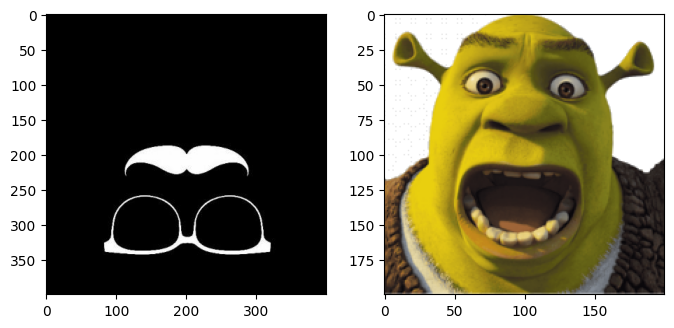

In [14]:
mustache = np.array(Image.open("mustache.jpg"))[:, :, :3]

shrek = np.array(Image.open("shrek.png"))[:, :, :3]

plt.figure(figsize=(8,8))

plt.subplot(2,2,1)
plt.imshow(mustache)
print(f"Dimensões do Mustache: {mustache.shape}")

plt.subplot(2,2,2)
plt.imshow(shrek)
print(f"Dimensões do Shrek: {shrek.shape}")

**3 -** Crie uma função que realize a reflexão no eixo x, essa função deve receber uma **imagem como parâmetro** e **retornar uma imagem refletida no eixo x**. Aplique essa função na imagem "mustache" aberta na questão anterior e mostre o resultado.

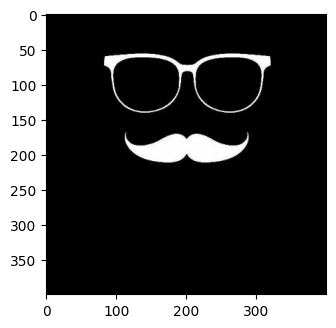

In [12]:
def reflexao(img):
    img_refl = np.zeros(shape=img.shape, dtype=np.uint8)
    img_refl[::-1, ::1] = img # Reflete a imagem no eixo X

    return img_refl

mustache_refl = reflexao(mustache)

plt.figure(figsize=(8,8))

plt.subplot(2,2,1)
plt.imshow(mustache_refl)

**4 -** Realize a operação lógica NOT com a imagem da questão anterior e mostre o resultado

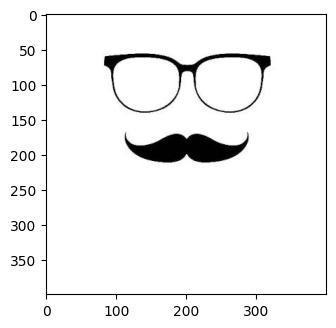

In [13]:
mustache_refl_not = ~mustache_refl

plt.figure(figsize=(8,8))

plt.subplot(2,2,1)
plt.imshow(mustache_refl_not)

**5 -** Crie uma função que realize o escalonamento de uma imagem que receba como parâmetro uma **imagem, sx e sy**, sendo sx e sy os fatores de escalonamento e **retorne a imagem escalonada**, em seguida aplique o escalonamento na imagem "shrek" para que fique do mesmo tamanho da imagem da questão anterior. Exiba o resultado.

(400, 400, 3)


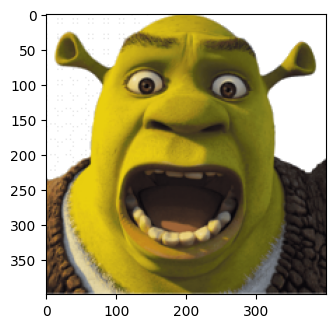

In [ ]:
def escala(img,sx,sy):
    (l,c,p) = img.shape

    ls, cs = l * sy, c * sx
    img_nn = np.zeros(shape=(ls, cs, p), dtype=np.uint8)

    for i in range(ls):
        for j in range(cs):
            new_y = int(np.floor(i * (l / ls)))
            new_x = int(np.floor(j * (c / cs)))
            
            img_nn[i, j] = img[new_y, new_x]
    
    return img_nn

shrek_esc = escala(shrek,2,2)

plt.figure(figsize=(8,8))

plt.subplot(2,2,1)
plt.imshow(shrek_esc)

**6 -** Realize o mascaramento (lógica E) entre as imagens das questões 4 e 5, exiba o resultado. 

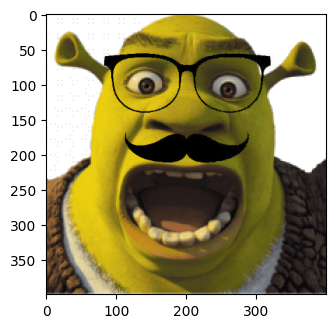

In [17]:
shrek_mustache = shrek_esc & mustache_refl_not

plt.figure(figsize=(8,8))

plt.subplot(2,2,1)
plt.imshow(shrek_mustache)

**7 -** Crie uma função para aplicar um método grayscale de sua escolha, que receba como parâmetro uma imagem e retorne uma imagem em greyscale. Aplique essa função na imagem resultante da questão anterior e mostre o resultado.

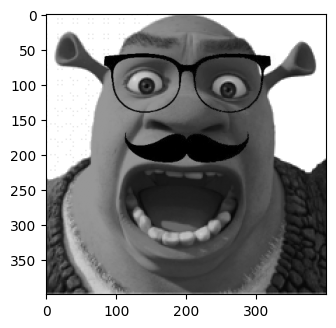

In [21]:
def grayscale(img):
    (l,c,p) = img.shape
    img_avg = np.zeros(shape=(l, c), dtype=np.uint8)
    for i in range(l):
        for j in range(c):
            r = float(img[i, j, 0])
            g = float(img[i, j, 1])
            b = float(img[i, j, 2])
            
            img_avg[i, j] = (r + g + b)/3
    return img_avg

shrek_mustache_gray = grayscale(shrek_mustache)

plt.figure(figsize=(8,8))

plt.subplot(2,2,1)
plt.imshow(shrek_mustache_gray,cmap="gray")

**8 -** Faça o cisalhamento na imagem, considere cx>cy.

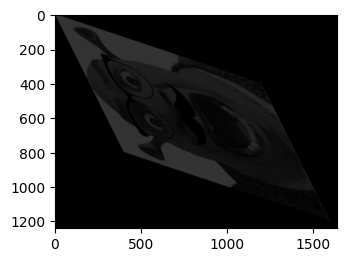

In [27]:
def cisalhamento(img,cx,cy):
    (l,c) = img.shape

    img_cis = np.zeros((int(l * (1.1 + cy)), int(c * (1.1 + cx))), dtype=np.uint8)

    for i in range(l):
        for j in range(c):
            new_x = int(j + cx * i)
            new_y = int(cy * j + i)

            img_cis[new_y,new_x] = img[i,j]

    return img_cis

shrek_mustache_gray_cis = cisalhamento(shrek_mustache_gray,3,2)

plt.figure(figsize=(8,8))

plt.subplot(2,2,1)
plt.imshow(shrek_mustache_gray_cis,cmap="gray")

    

**9 -** Salve a imagem da questão anterior no disco com o nome "resultado.jpg"

In [28]:
Image.fromarray(shrek_mustache_gray_cis).save("resultado.jpg") #carregado para o disco do computador